# Numpy and Matplotlib synthesis exercise


Read the data file `Variability_Catalina_list1.csv` which contains lightcurves of an ensemble of objectsobserved in the context of the Catalina survey (http://nesssi.cacr.caltech.edu/DataRelease/). 

This file contains the following columns separated by 'tab' characters: `InputID	ID	Mag	Magerr	RA	Decl	MJD	Blend`. Their meaning is the following: 
* [0] `InputID`: Object Name 
* [1] `ID`: Object ID in the survey
* [2] `Mag`: Object Magnitude ($ m = -2.5 * \log(Flux)$ + zeropoint)
* [3] `Magerr`: Formal error on the magnitude
* [4] `RA`: Right ascension  (degrees)
* [5] `Decl`: Declination  (degrees)
* [6] `MJD`: Modified julian day (day). 
* [7] `Blend`: 0 if the measurement is clean, 1 if there is a possible contamination by another target. 

The file contains the observed magnitude of the following (gravitationally lensed) quasars: 'DESJ0407-5006', 'HE1104-1805', 'HS2209+1914' 'J0011-0845', 'J0228+3953', 'Q1355-2257', 'SDSSJ0904+1512'. 
You want to visualise the lightcurve (x=MJD, y=Mag, yerr=Maggerr) associated to each individual object. You also want to measure its mean magnitude, and the standard deviation on the magnitude, as well as its minimum / maximum magnitude over the period of observation and save those value into a table. Try to reach this goal using only "standard" python commands and commands from numpy and matplotlib arrays. To ease your task, a possible methodology is outlined below.  

**Possible methodology:**
- (1) Read the file and save the output into a numpy array. How many rows and columns does contain the array ? What is the dtype of your array ? 
- (2) Create a sub-array for a single object (e.g. HS2209+1914) using fancy indexing. 
- (3) create an array with 4 columns `MJD, Mag, magerr, blend` , converting strings to floats.
- (4) Get rid of data points with Blend > 0 
- (5) Plot the lightcurve at the screen 
- (6) Calculates mean, std, min, max with numpy 
- (7) Repeat the operation for the 7 object using a for loop.i.e. you can create a list of arrays, each one containing MJD, mag, magerr for each object. In the same loop you can make a plot. You can include the plotting in the loop. To plot into a single figure, think of using plt.subplots(rows=7, figsize=(15,20)). 
- BONUS: How would you proceed to know the names of the individual objects if I did not provide the list ? 

**TIPs:** 

* A file's row mixes strings and floats. You may therefore first create an array of strings (1 single dtype in an array). One of the arguments of `np.loadtxt()` is the data type, so you can read a list of strings with `np.loadtxt(filename, dtype=str)`
* To convert an array of numbers whose type is strings into float: 
``` python 
myarray_strings = np.array(['1', '2', '3'])  
myarray_floats = np.array(myarray_strings , dtype = float)
```

In [1]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

**(1) Read the file and save the output into a numpy array**. How many rows and columns does contain the array ? What is the dtype of your array ? 

In [2]:
data_file = 'Variability_Catalina_list1.csv'
data = np.loadtxt(data_file, dtype=str)

In [3]:
data

array([['J0011-0845', '1009002045103', '19.19', ..., '-8.76392',
        '53711.14915', '0'],
       ['J0011-0845', '1009002045103', '19.17', ..., '-8.76410',
        '53711.15716', '0'],
       ['J0011-0845', '1009002045103', '20.03', ..., '-8.76453',
        '53677.20006', '0'],
       ...,
       ['HS2209+1914', '1118114081112', '15.37', ..., '19.48718',
        '56587.16828', '0'],
       ['HS2209+1914', '1118114081112', '15.33', ..., '19.48713',
        '56587.17481', '0'],
       ['HS2209+1914', '1118114081112', '15.33', ..., '19.48708',
        '56587.18086', '0']], dtype='<U14')

In [4]:
data.shape

(2308, 8)

Note that `np.loadtxt()` would allow you to directly create 2 arrays: one array containing only characters (i.e. `dtype=str`) associated to the object names, and one arrays with floats corresponding to the quantities of interest. This allows you to skip the conversion step (as performed below). 

In [5]:
# Alternative [not used in the following]
datanames = np.loadtxt(data_file, dtype=str, usecols=(0))  # Read the names in the first col
datavalues = np.loadtxt(data_file, dtype=float, usecols=range(1,8))    # read the other columns directly as floats
datanames, datavalues
                       

(array(['J0011-0845', 'J0011-0845', 'J0011-0845', ..., 'HS2209+1914',
        'HS2209+1914', 'HS2209+1914'], dtype='<U14'),
 array([[ 1.00900205e+12,  1.91900000e+01,  1.90000000e-01, ...,
         -8.76392000e+00,  5.37111491e+04,  0.00000000e+00],
        [ 1.00900205e+12,  1.91700000e+01,  1.90000000e-01, ...,
         -8.76410000e+00,  5.37111572e+04,  0.00000000e+00],
        [ 1.00900205e+12,  2.00300000e+01,  2.90000000e-01, ...,
         -8.76453000e+00,  5.36772001e+04,  0.00000000e+00],
        ...,
        [ 1.11811408e+12,  1.53700000e+01,  6.00000000e-02, ...,
          1.94871800e+01,  5.65871683e+04,  0.00000000e+00],
        [ 1.11811408e+12,  1.53300000e+01,  6.00000000e-02, ...,
          1.94871300e+01,  5.65871748e+04,  0.00000000e+00],
        [ 1.11811408e+12,  1.53300000e+01,  6.00000000e-02, ...,
          1.94870800e+01,  5.65871809e+04,  0.00000000e+00]]))

A third possibility to read the array would be to use `astropy.table()`  but the goal of this exercise is really to work with numpy array so we will not detail that solution. The cell below will show how to read the table with astropy and then create an array from the astropy table. The procedure would be as follows.

In [7]:
from astropy.table  import Table 
data_tab = Table.read(data_file, format='ascii', )
data_tab

InputID,ID,Mag,Magerr,RA,Decl,MJD,Blend
str14,int64,float64,float64,float64,float64,float64,int64
J0011-0845,1009002045103,19.19,0.19,2.83433,-8.76392,53711.14915,0
J0011-0845,1009002045103,19.17,0.19,2.83464,-8.7641,53711.15716,0
J0011-0845,1009002045103,20.03,0.29,2.83461,-8.76453,53677.20006,0
J0011-0845,1009002045103,19.71,0.25,2.83457,-8.76412,53677.21198,0
J0011-0845,1009002045103,18.85,0.16,2.83509,-8.76393,53704.2,0
J0011-0845,1009002045103,20.11,0.31,2.83421,-8.76462,53704.20858,0
J0011-0845,1009002045103,19.31,0.21,2.8345,-8.76421,53648.28483,0
J0011-0845,1009002045103,19.33,0.22,2.83428,-8.7642,53648.29019,0
J0011-0845,1009002045103,19.62,0.25,2.83446,-8.76405,53648.29558,0


In [8]:
# we can then create an array with 4 columns containing MJD, mag, magerr, blend as follows

data_from_tab = np.array([data_tab['MJD'], data_tab['Mag'], data_tab['Magerr'], data_tab['Blend']], dtype=float)
obj_name_from_tab = np.array(data_tab['InputID'])

In [11]:
# let's have a look to the created arrays with obj. names
obj_name_from_tab, obj_name_from_tab.shape

(array(['J0011-0845', 'J0011-0845', 'J0011-0845', ..., 'HS2209+1914',
        'HS2209+1914', 'HS2209+1914'], dtype='<U14'), (2308,))

In [12]:
# let's have a look to the created arrays with the columns of interes
data_from_tab, data_from_tab.shape

(array([[5.37111491e+04, 5.37111572e+04, 5.36772001e+04, ...,
         5.65871683e+04, 5.65871748e+04, 5.65871809e+04],
        [1.91900000e+01, 1.91700000e+01, 2.00300000e+01, ...,
         1.53700000e+01, 1.53300000e+01, 1.53300000e+01],
        [1.90000000e-01, 1.90000000e-01, 2.90000000e-01, ...,
         6.00000000e-02, 6.00000000e-02, 6.00000000e-02],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]]), (4, 2308))

**(2) Create a sub-array for a single object (e.g. HS2209+1914)** using fancy indexing. 

I identify the unique object names in my array. (THIS IS THE ANSWWER TO THE **BONUS**)

In [13]:
objnames = data[:,0]
objnames

array(['J0011-0845', 'J0011-0845', 'J0011-0845', ..., 'HS2209+1914',
       'HS2209+1914', 'HS2209+1914'], dtype='<U14')

In [14]:
list_of_objects = list(set(objnames))
list_of_objects

['SDSSJ0904+1512',
 'HS2209+1914',
 'Q1355-2257',
 'J0011-0845',
 'J0228+3953',
 'DESJ0407-5006',
 'HE1104-1805']

I want to create a list of arrays containing MJD, mag, magerr for each object, removing observations with blend > 0.   
For this purpose, let's first see how to select the rows associated to a single object using fancy indexing: 

In [15]:
objnames == 'HS2209+1914'

array([False, False, False, ...,  True,  True,  True])

In [16]:
# Let's save this condition into a mask 
mask = objnames == 'HS2209+1914'
mask.shape

(2308,)

In [17]:
# And now let's apply it tou our data array 
data_HS2209 = data[data[:,0] == 'HS2209+1914']
# data_HS2209 = data[mask]   # alternative syntax
data_HS2209

array([['HS2209+1914', '1118114081112', '15.33', ..., '19.48714',
        '53480.47892', '0'],
       ['HS2209+1914', '1118114081112', '15.32', ..., '19.48717',
        '53480.48282', '0'],
       ['HS2209+1914', '1118114081112', '15.31', ..., '19.48713',
        '53480.48672', '0'],
       ...,
       ['HS2209+1914', '1118114081112', '15.37', ..., '19.48718',
        '56587.16828', '0'],
       ['HS2209+1914', '1118114081112', '15.33', ..., '19.48713',
        '56587.17481', '0'],
       ['HS2209+1914', '1118114081112', '15.33', ..., '19.48708',
        '56587.18086', '0']], dtype='<U14')

**(3) create an array with 4 columns** `MJD, Mag, magerr, blend` , converting strings to floats.

In [18]:
col_of_interest = np.array([6, 2, 3, 7])   # MJD=col[6], Mag=col[2], Magerr=col[3], Blend=col[7]
lightcurve_HS2209 = np.array(data_HS2209[:, col_of_interest], dtype=float)

In [19]:
# Alternative command set to convert to floats 
subarray = data_HS2209[:, col_of_interest]
subarray_float = subarray.astype(np.float)

In [22]:
# FYI: If you want to check wether the latter cells yields views or copies
np.shares_memory(subarray, data), np.shares_memory(subarray, data_HS2209)

(False, False)

In [24]:
# But beware that if you had selected only e.g. the 1st column, 
# the behaviour would have been different (don't ask why)
test_subarray = data_HS2209[:, 0]
np.shares_memory(test_subarray, data_HS2209) # This is now a view 

True

**(4) Get rid of data points with Blend > 0** 
We can use fancy indexing ! `lightcurve_HS2209[:,3] < 1` will return an array of booleans for which blend == 0. 

In [25]:
lightcurve_HS2209.shape

(371, 4)

In [26]:
lightcurve_HS2209.dtype

dtype('float64')

In [27]:
lightcurve_HS2209 = lightcurve_HS2209[lightcurve_HS2209[:,3] < 0.1]   

In [28]:
lightcurve_HS2209.shape

(371, 4)

**(5) Plot the lightcurve at the screen**

Text(0, 0.5, 'Mag')

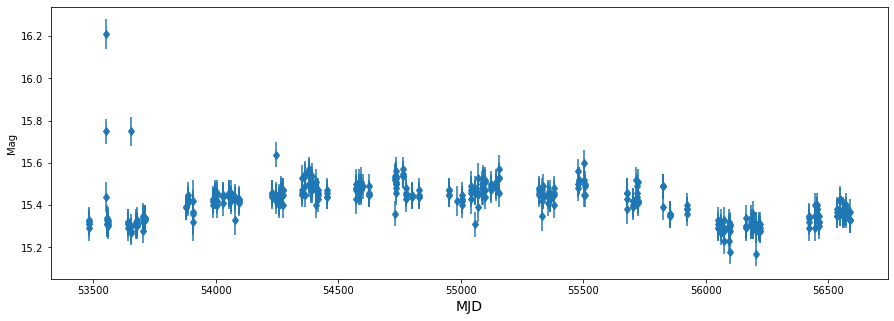

In [29]:
f, ax = plt.subplots(nrows=1, figsize=(15,5))
ax.errorbar(lightcurve_HS2209[:,0], lightcurve_HS2209[:,1], yerr=lightcurve_HS2209[:,2], ls='', marker='d')
ax.set_xlabel('MJD', fontsize=14)
ax.set_ylabel('Mag')

**(6) Calculates mean, std, min, max with numpy** 

In [30]:
#print('Mean = %.2f mag' %lightcurve_HS2209[:,1].mean())
print('Mean = %.2f mag' %np.nanmean(lightcurve_HS2209[:,1]))  # an alternative that enable to manage nan 
print('Std = %.2f mag' %lightcurve_HS2209[:,1].std())
print('Min = %.2f mag' %lightcurve_HS2209[:,1].min())
print('Max = %.2f mag' %lightcurve_HS2209[:,1].max())

Mean = 15.42 mag
Std = 0.09 mag
Min = 15.17 mag
Max = 16.21 mag


Save those values into an array (for which the first column will be an arbitrary float ID

In [31]:
res = np.zeros(5, dtype=float)
res[1] = lightcurve_HS2209[:,1].mean()
res[2] = lightcurve_HS2209[:,1].std()
res[3] = lightcurve_HS2209[:,1].min()
res[4] = lightcurve_HS2209[:,1].max()

(7) **Repeat the operation for the 7 objects** using a for loop.i.e. you can create a list of arrays, each one containing `MJD, mag, magerr` for each object. In the same loop you can make a plot. You can include the plotting in the loop. To plot into a single figure, think of using `plt.subplots(rows=7, figsize=(15,20))`. 

Now, we generalise to all the objects, and create a single figure with all the targets. 

Ideally, instead of putting everything into a big cell, you would create a function that calculates the quantities of interest and make the plots. 

Text(0.5, 0, 'MJD')

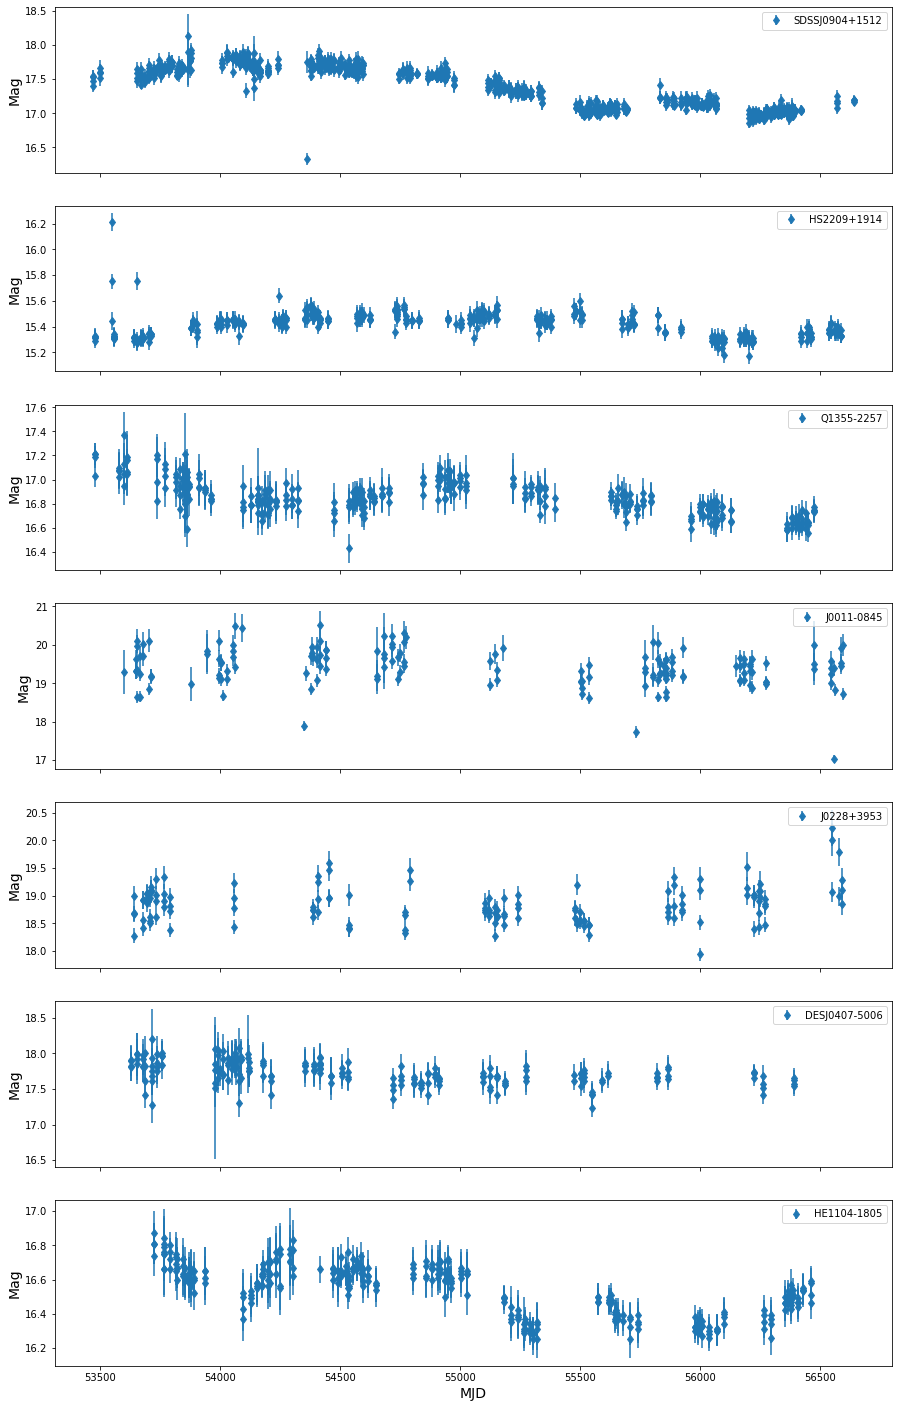

In [32]:
lightcurves = []  # I'll make a list of lcves, each entry in the list being a lcve associated to a given object
f, ax = plt.subplots(nrows=7, figsize=(15,25), sharex=True)
res = np.zeros(shape=(7,5))  # 7 objects, 5 columns: ID, mean, std, min, max
for i, objname in enumerate(list_of_objects):
    data_sub = data[data[:,0]==objname]  # select the object of interest
    lcv = np.array(data_sub[:, col_of_interest], dtype=float)   # Create a subarray with the associated lcve
    lcv = lcv[lcv[:,3] < 0.1]   # Remove the blends 
    lightcurves.append(lcv)   # Append the lcve to the list
    # Save summary information on each object into a list 
    res[i, 0] = i                
    res[i, 1] = lcv[:,1].mean()
    res[i, 2] = lcv[:,1].std()
    res[i, 3] = lcv[:,1].min()
    res[i, 4] = lcv[:,1].max()
    # plot the lightcurves for each object 
    ax[i].errorbar(lcv[:,0], lcv[:,1], yerr=lcv[:,2], ls='', marker='d', label=objname)
    ax[i].set_ylabel('Mag', fontsize=14)   # add ylabel
    ax[i].legend()   # add legent
ax[6].set_xlabel('MJD', fontsize=14)  # add xlabel 

The table with the results of interest

In [33]:
res

array([[ 0.        , 17.38941476,  0.29853487, 16.33      , 18.13      ],
       [ 1.        , 15.4187062 ,  0.09287819, 15.17      , 16.21      ],
       [ 2.        , 16.85125   ,  0.13809504, 16.43      , 17.37      ],
       [ 3.        , 19.41538462,  0.48859477, 17.04      , 20.52      ],
       [ 4.        , 18.8423913 ,  0.33894456, 17.94      , 20.22      ],
       [ 5.        , 17.73141414,  0.1630115 , 17.24      , 18.21      ],
       [ 6.        , 16.54213376,  0.14620758, 16.25      , 16.87      ]])

In [22]:
np.savetxt('results_lcves.txt', res)